#### 0) Import Libraries

In [59]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
from pathlib import Path
import matplotlib.pyplot as plt

#### Define Trading Hypothesis

Before constructing the signals, we must codify the trading logic. A moving average crossover strategy operates on the principle of trend momentum: a short-term moving average crossing above a long-term moving average suggests an emerging uptrend, while a cross below suggests a trend reversal or exhaustion. To ensure backtest integrity, we explicitly introduce a lag to our signals, ensuring that today's decision is only executed based on information available at the close of the previous day, thereby eliminating look-ahead bias. Furthermore, we treat auxiliary indicators like the 200-day trend filter as independent modules, allowing for modular A/B testing in later stages of our analysis.nclusion)

#### 1) Signal Configs

In [60]:
# Strategy Parameters
CONFIG = {
    "sma_short" : 9, # 9 days rolling window
    "sma_long" : 21, # 21 days rolling window
    "trend_window" : 200, # 200 days rolling window
    "ma_type" : ["SMA","EMA"], # the other option is EMA
    "use_trend_filter" : True,
    "tickers" : ["AAPL","META","MSFT","TSLA"]
}

output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

#### 2) Signal Construction Logic

In [61]:
for ticker in CONFIG["tickers"]:
    df = pd.read_parquet(output_dir / f"ohlcv_{ticker}.parquet")

    # Calculate SMAs
    df['SMA_short'] = df['Close'].rolling(window=CONFIG["sma_short"]).mean()
    df['SMA_long'] = df['Close'].rolling(window=CONFIG["sma_long"]).mean()
    df['SMA_trend'] = df['Close'].rolling(window=CONFIG["trend_window"]).mean()
    
    # Calculate EMAs
    df['EMA_short'] = df['Close'].ewm(span=CONFIG["sma_short"], adjust=False).mean()
    df['EMA_long'] = df['Close'].ewm(span=CONFIG["sma_long"], adjust=False).mean()
    df['EMA_trend'] = df['Close'].ewm(span=CONFIG["trend_window"], adjust=False).mean()

    # Generate SMA Signals and Returns
    df['signal_SMA'] = np.where(df['SMA_short'] > df['SMA_long'], 1, 0)
    df['trend_filter_SMA'] = np.where(df['Close'] > df['SMA_trend'], 1, 0)
    df['final_position_SMA'] = (df['signal_SMA'] * df['trend_filter_SMA']).shift(1)
    df['returns_SMA'] = df['final_position_SMA'] * df['Close'].pct_change()

    # Generate EMA Signals and Returns
    df['signal_EMA'] = np.where(df['EMA_short'] > df['EMA_long'], 1, 0)
    df['trend_filter_EMA'] = np.where(df['Close'] > df['EMA_trend'], 1, 0)
    df['final_position_EMA'] = (df['signal_EMA'] * df['trend_filter_EMA']).shift(1)
    df['returns_EMA'] = df['final_position_EMA'] * df['Close'].pct_change()

    # Save the processed signals
    table = pa.Table.from_pandas(df)
    pq.write_table(table, output_dir / f"signals_{ticker}.parquet")
    
               

#### 3) Visualization & Cumulative Returns

[AAPL] 50 Day Returns:
SMA Strategy: 3.67%
EMA Strategy: 8.58%


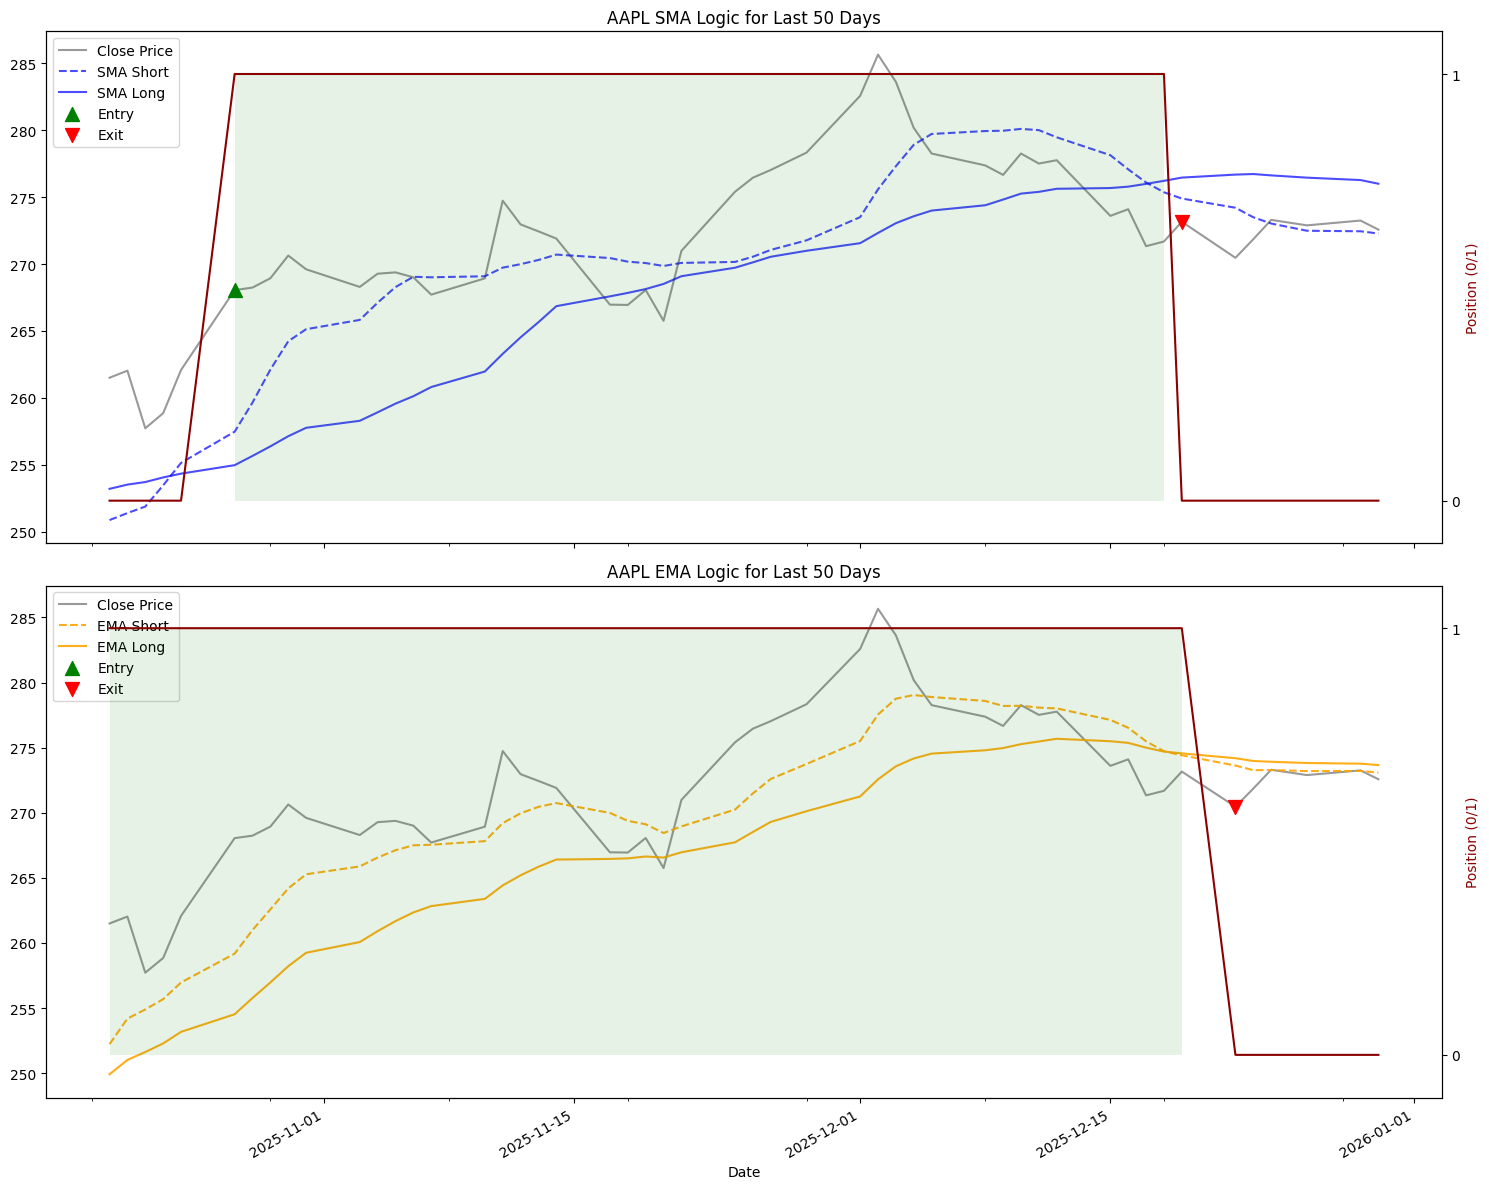

[AAPL] 100 Day Returns:
SMA Strategy: 12.92%
EMA Strategy: 24.64%


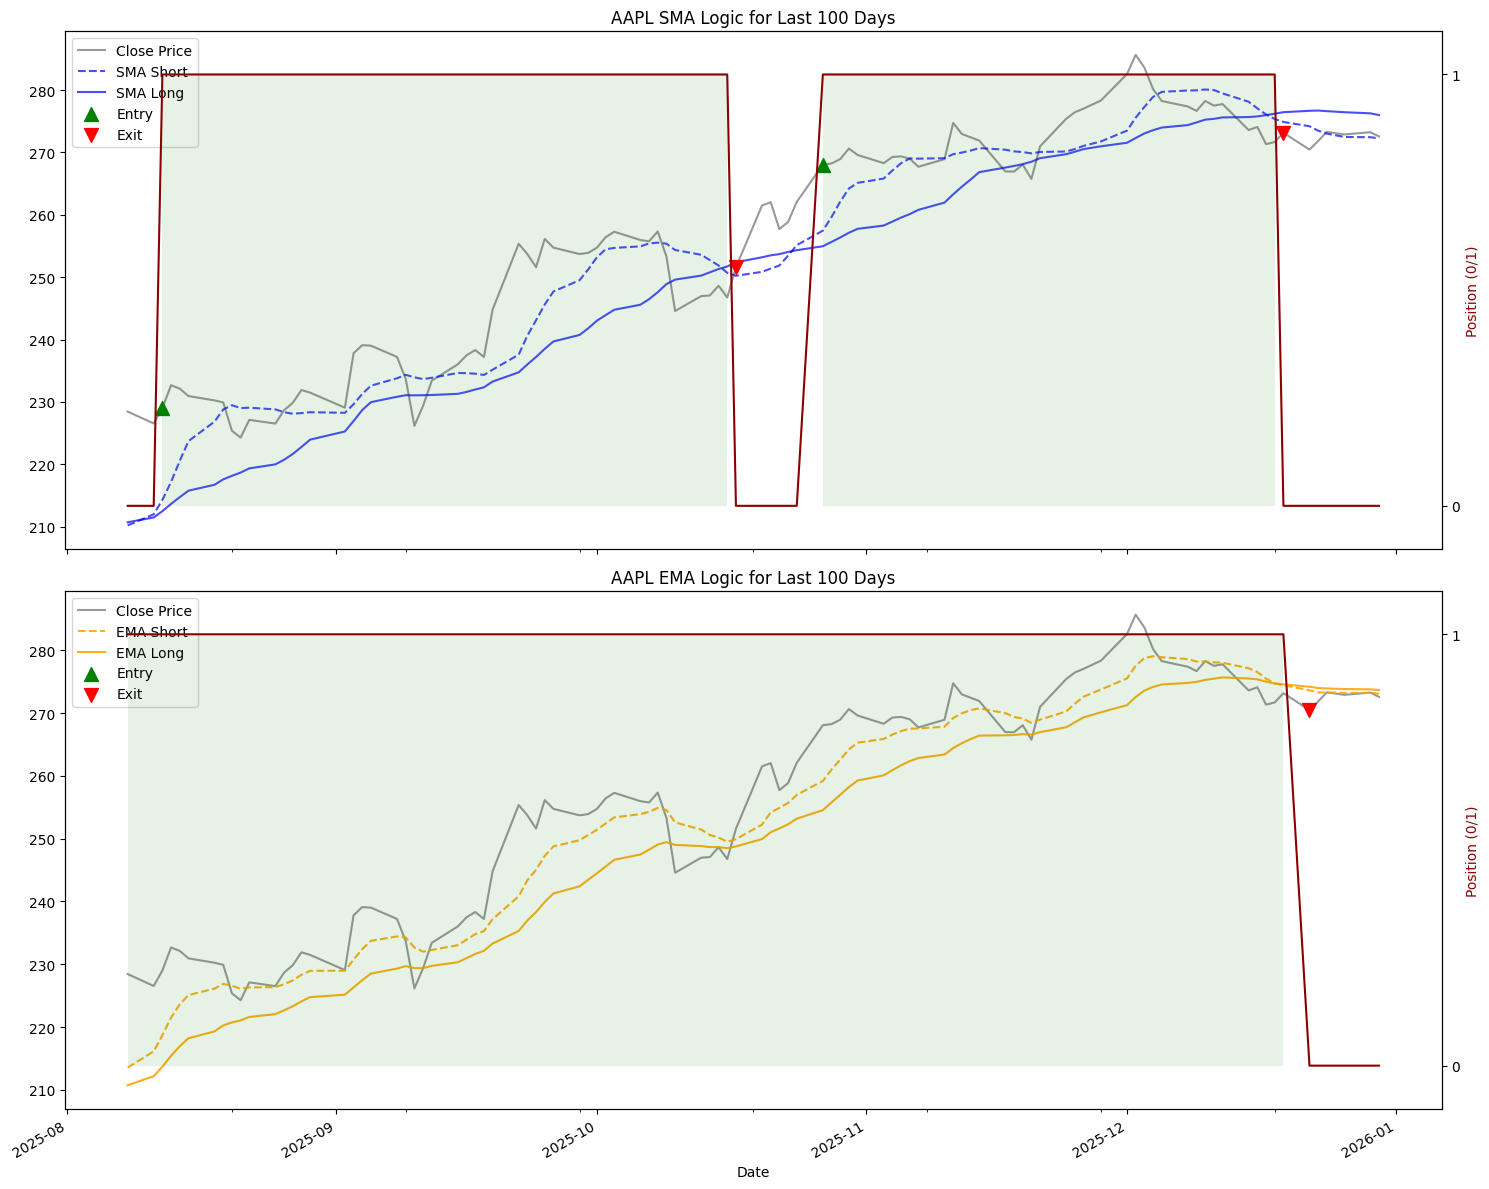

[AAPL] 150 Day Returns:
SMA Strategy: 12.92%
EMA Strategy: 20.75%


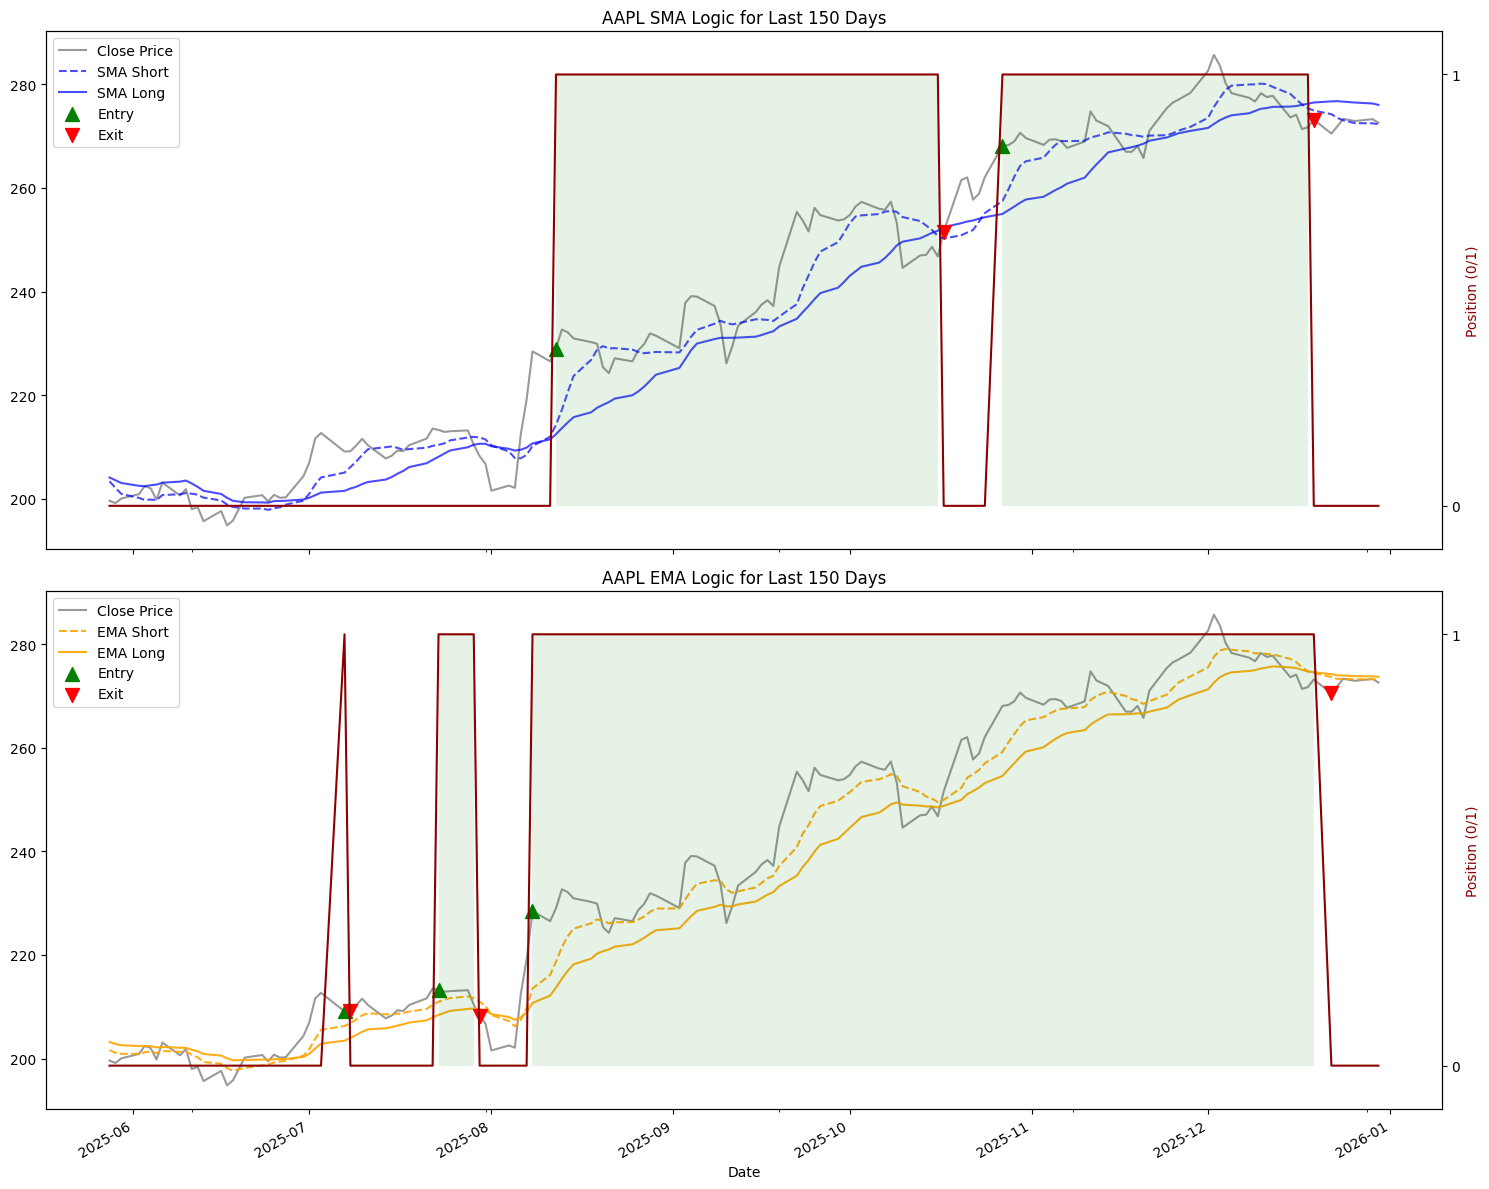

[AAPL] 200 Day Returns:
SMA Strategy: 12.92%
EMA Strategy: 20.75%


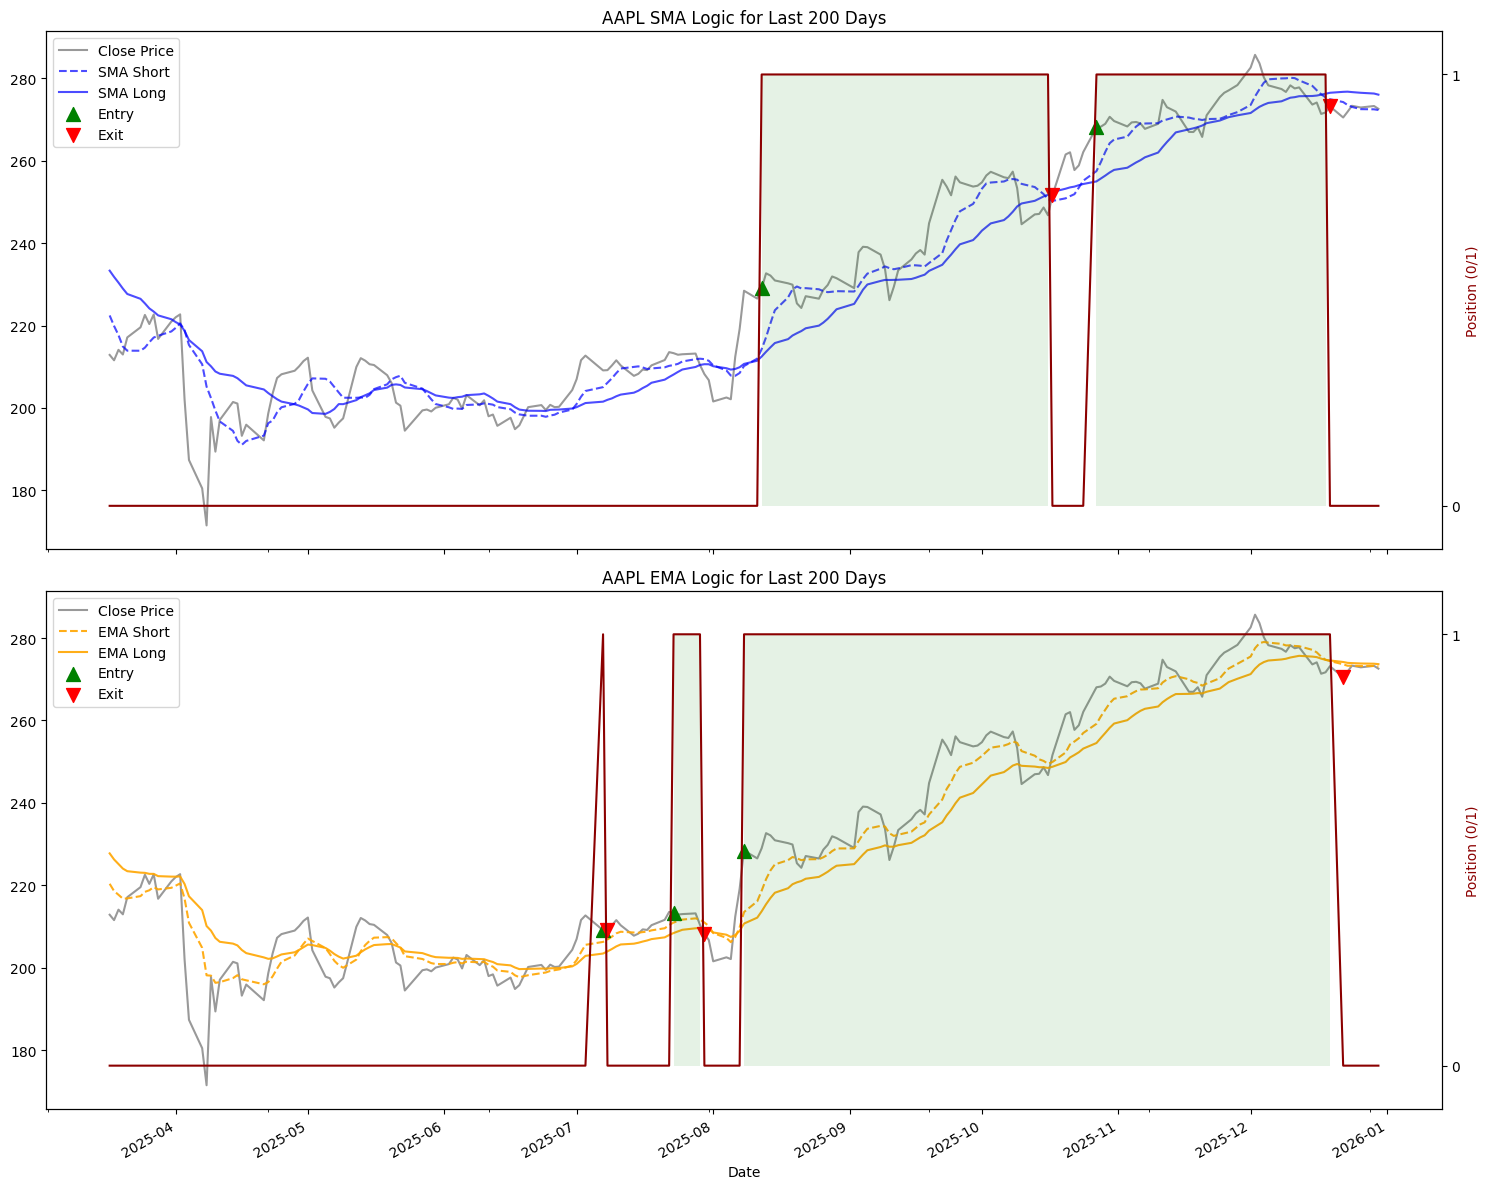

[META] 50 Day Returns:
SMA Strategy: -10.62%
EMA Strategy: -12.67%


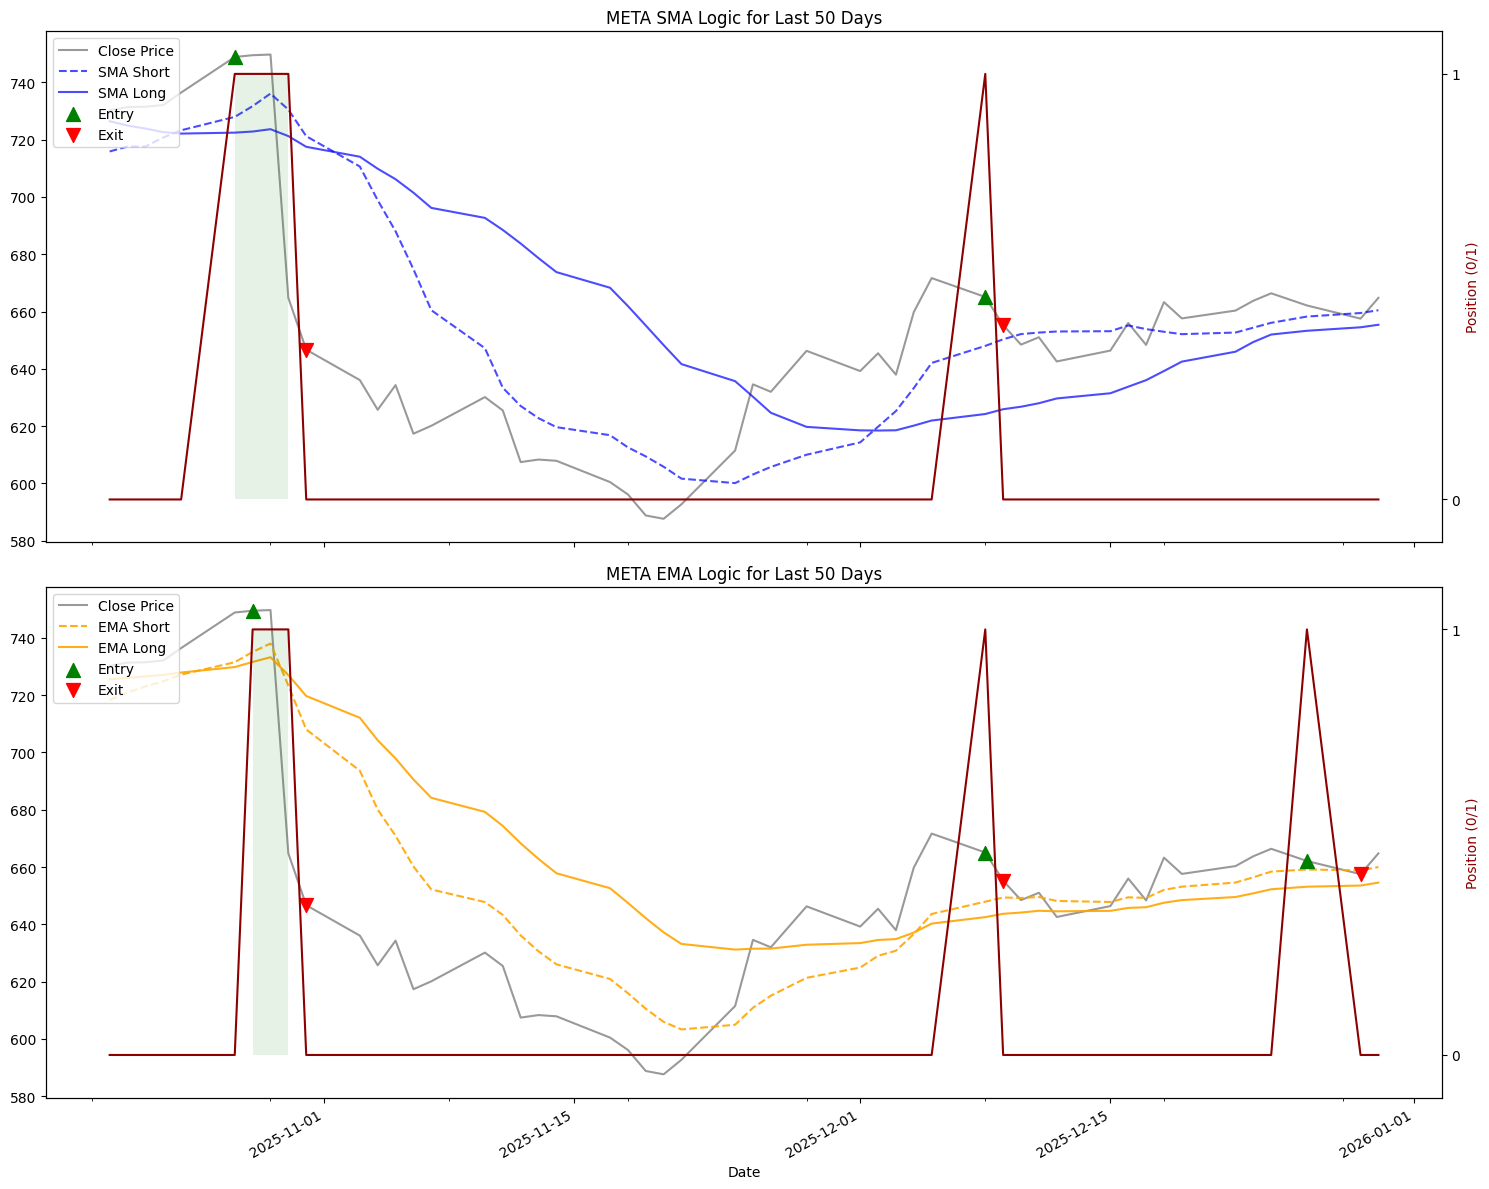

[META] 100 Day Returns:
SMA Strategy: -17.69%
EMA Strategy: -17.69%


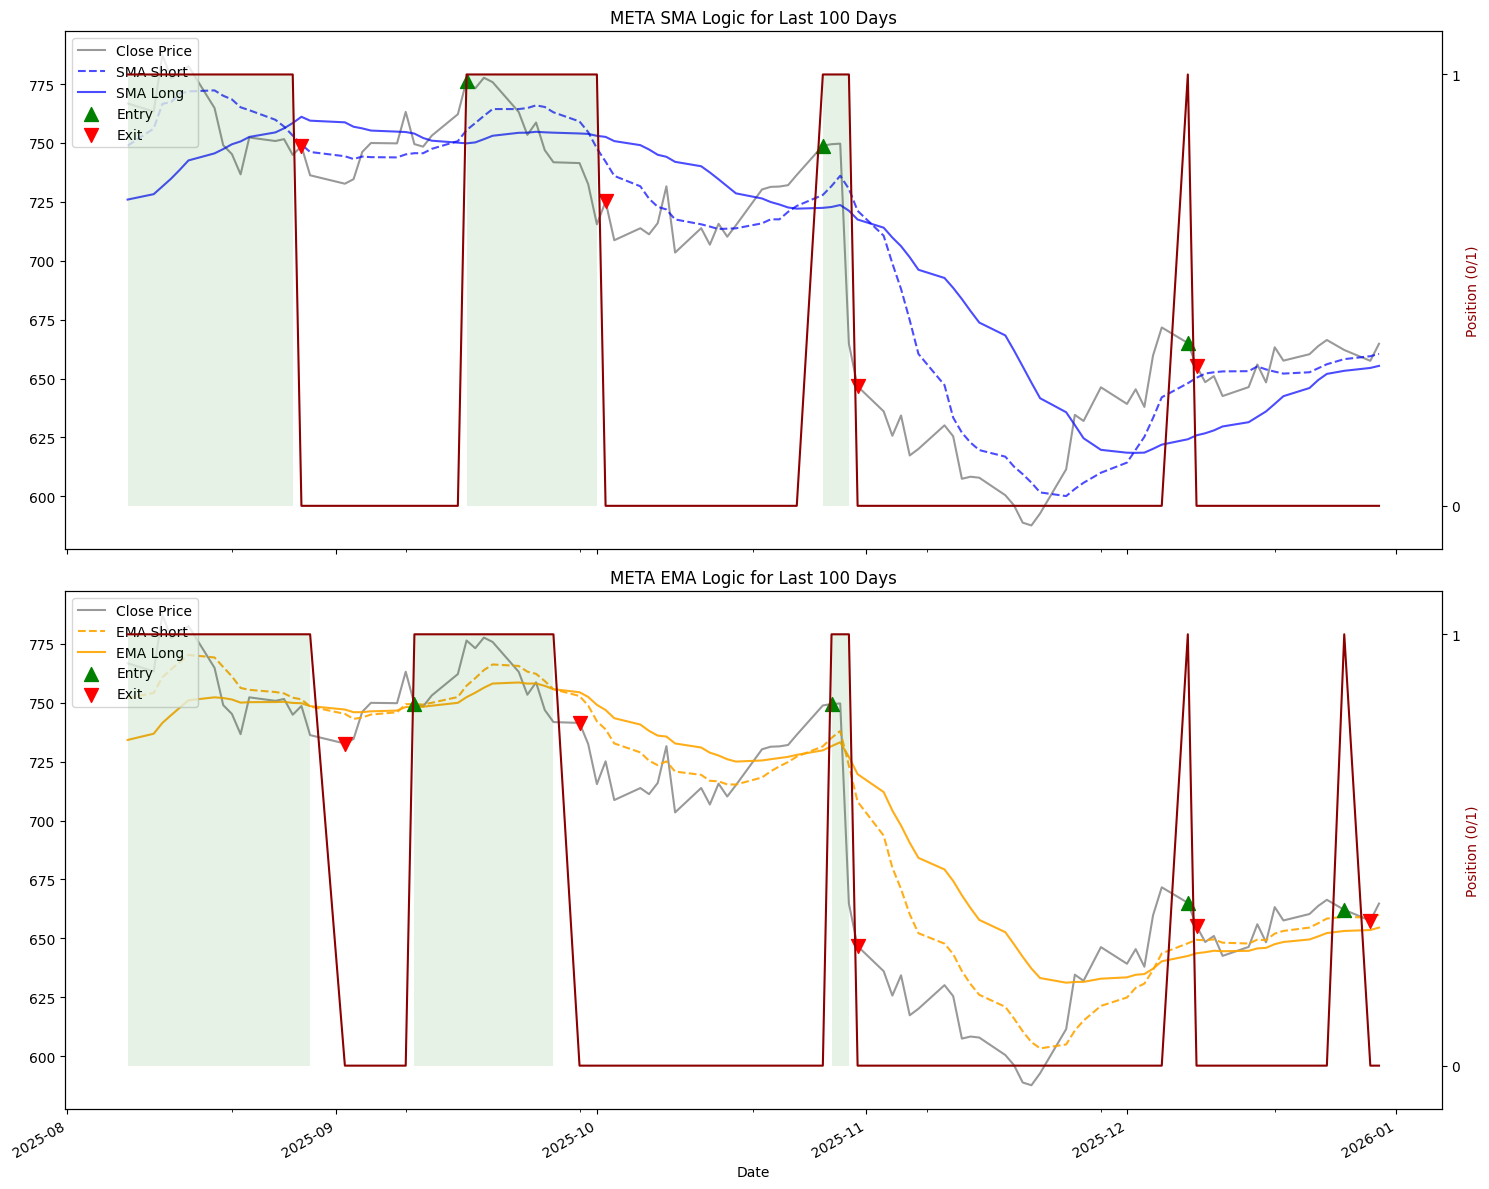

[META] 150 Day Returns:
SMA Strategy: -9.94%
EMA Strategy: -12.18%


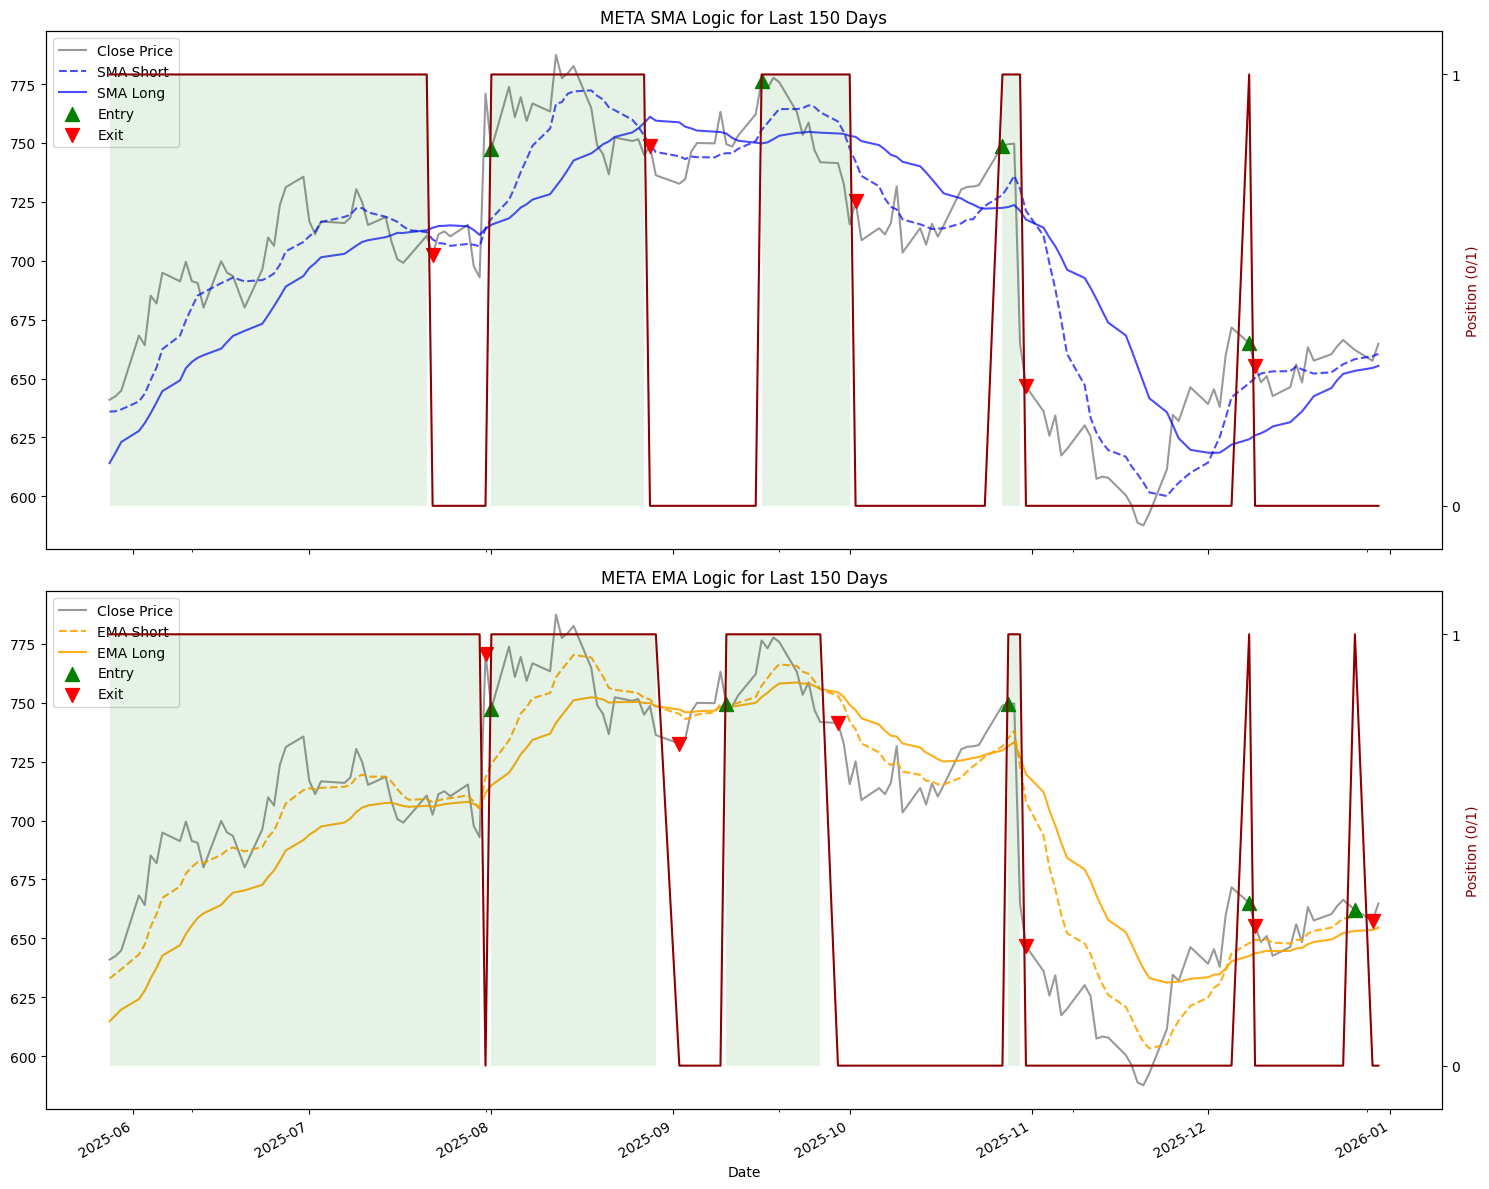

[META] 200 Day Returns:
SMA Strategy: -3.11%
EMA Strategy: -5.52%


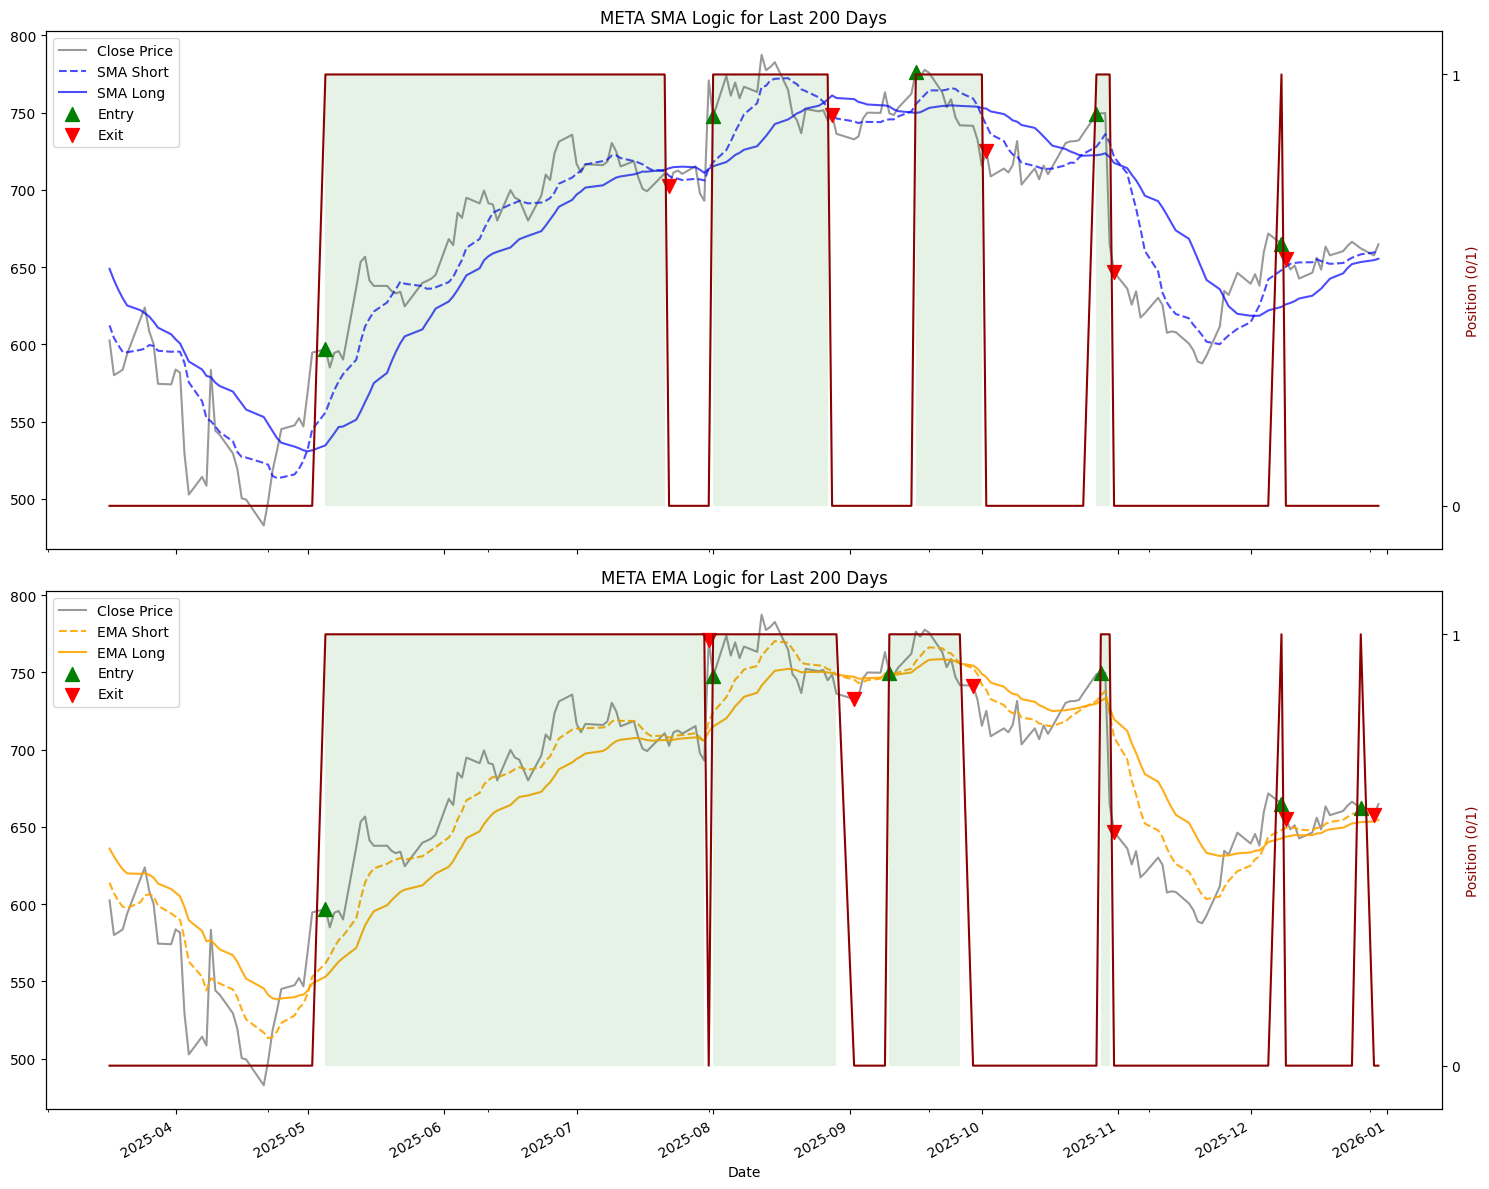

[MSFT] 50 Day Returns:
SMA Strategy: -4.13%
EMA Strategy: -1.25%


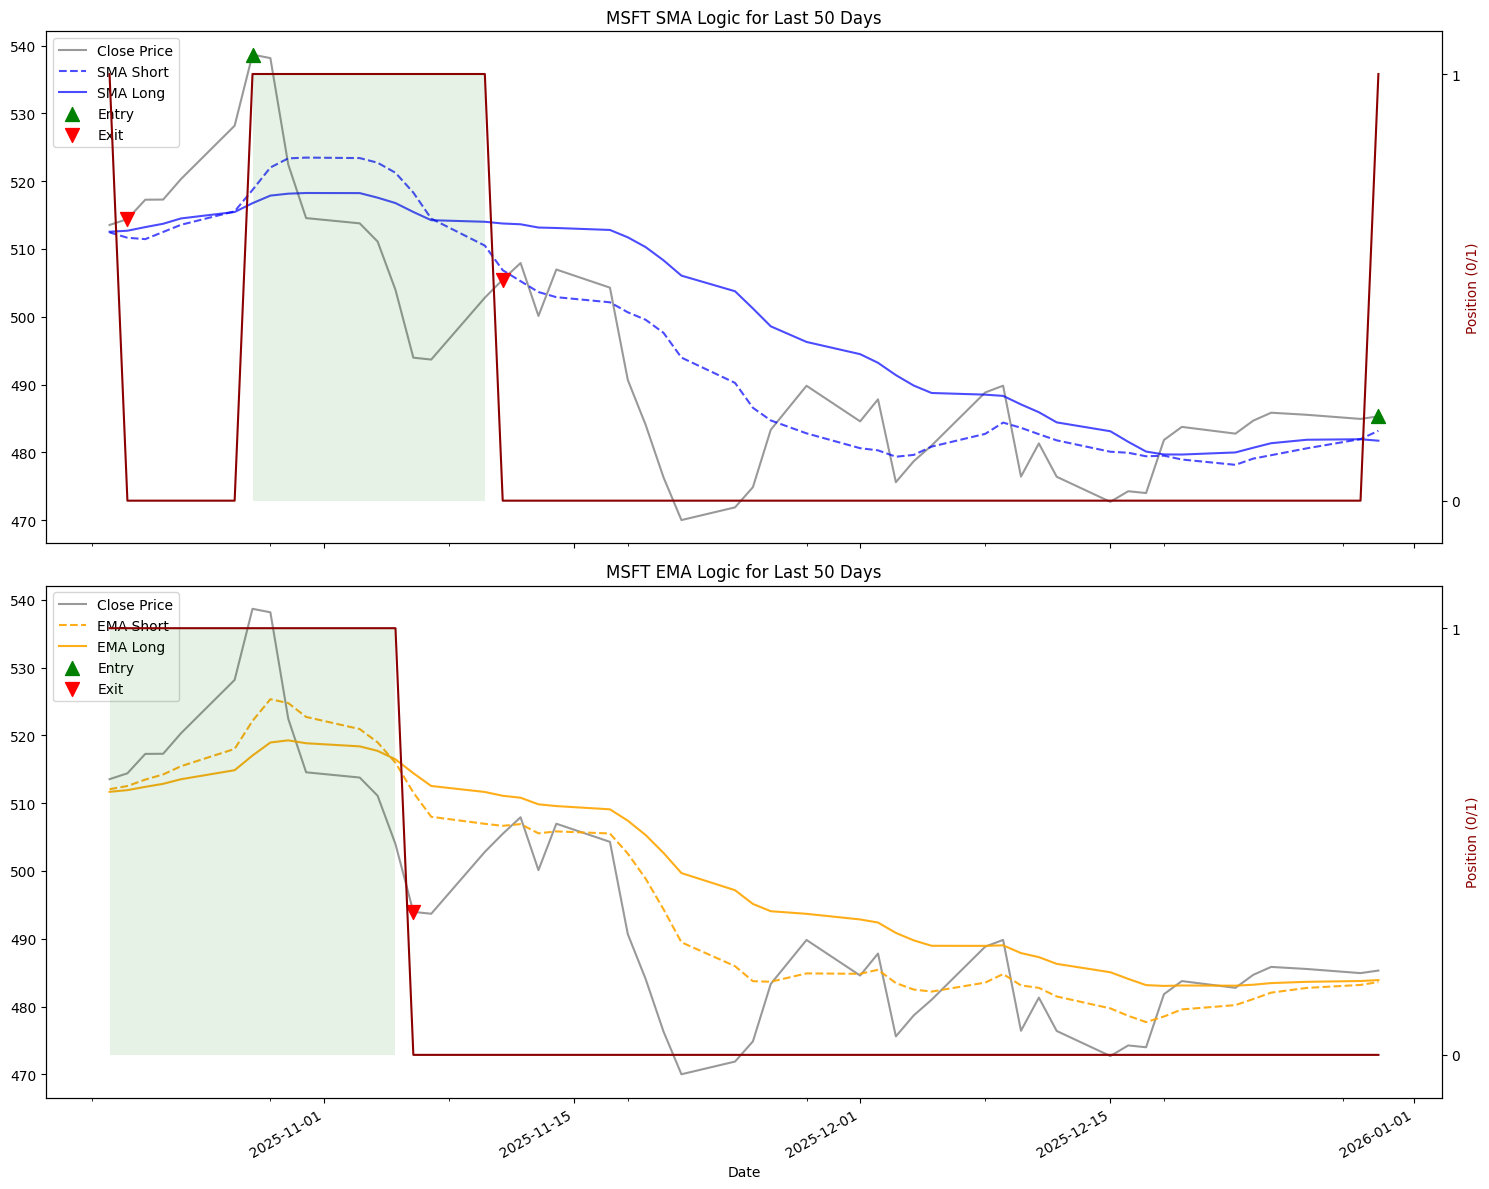

[MSFT] 100 Day Returns:
SMA Strategy: -5.98%
EMA Strategy: -3.27%


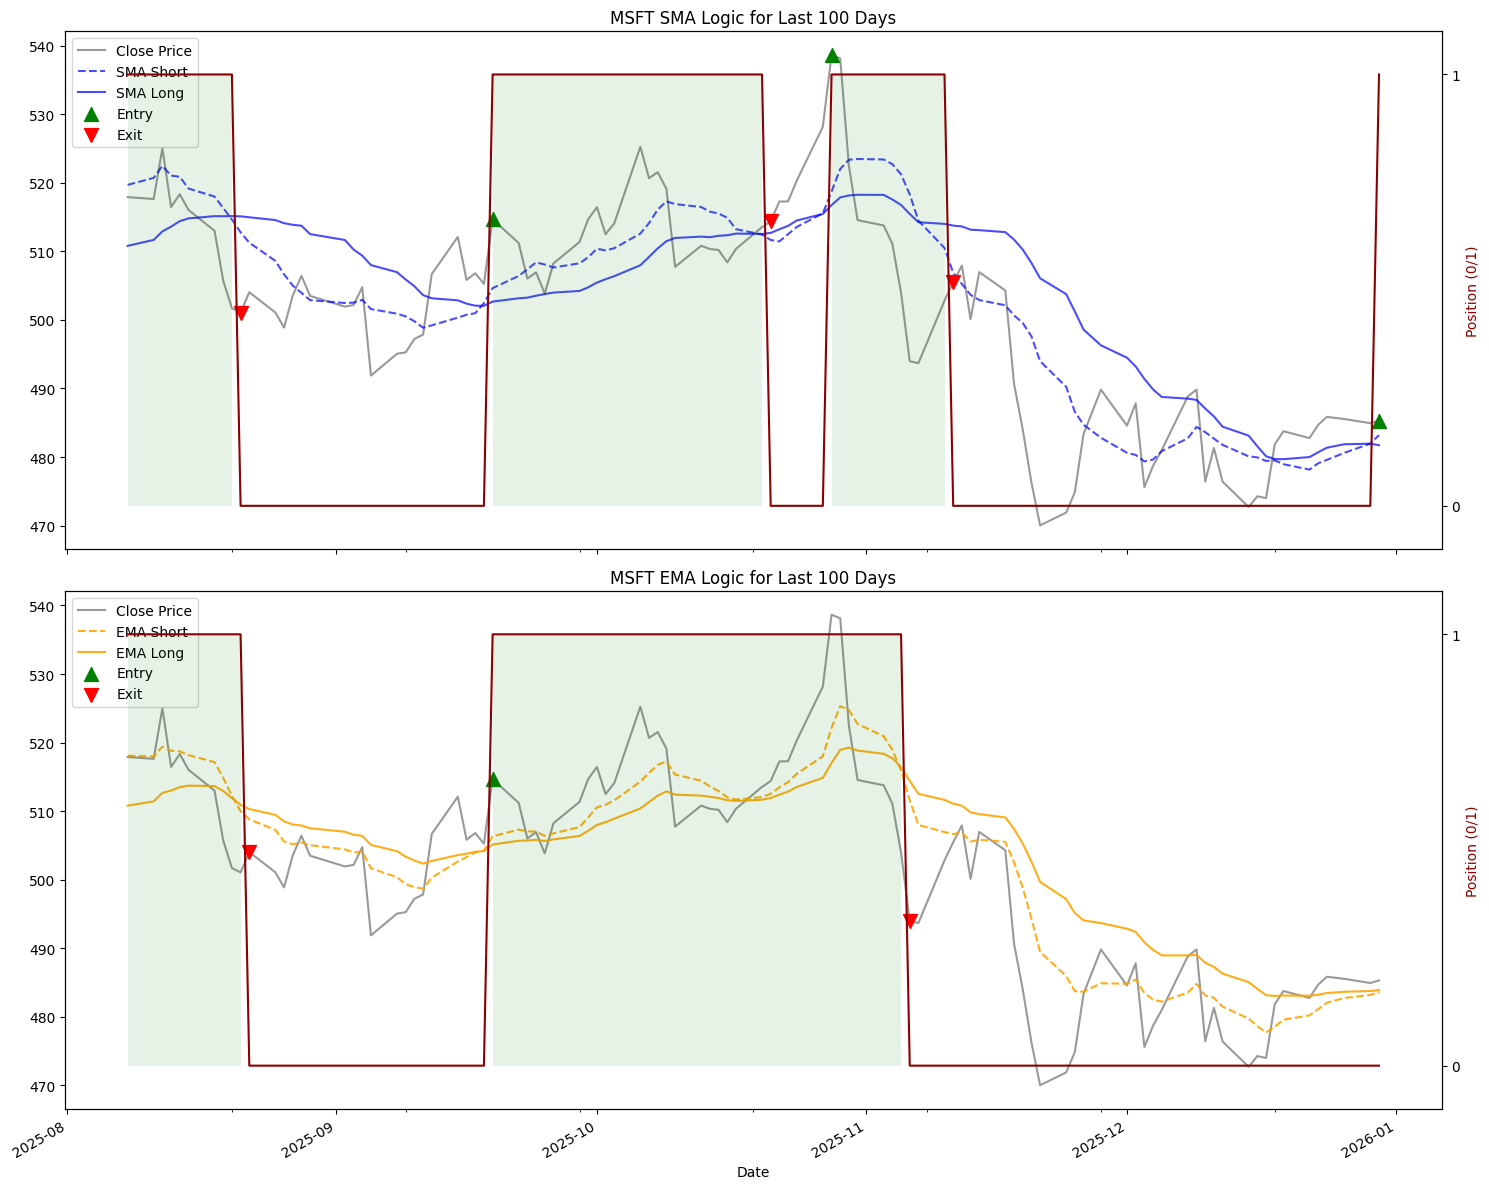

[MSFT] 150 Day Returns:
SMA Strategy: 6.30%
EMA Strategy: 9.35%


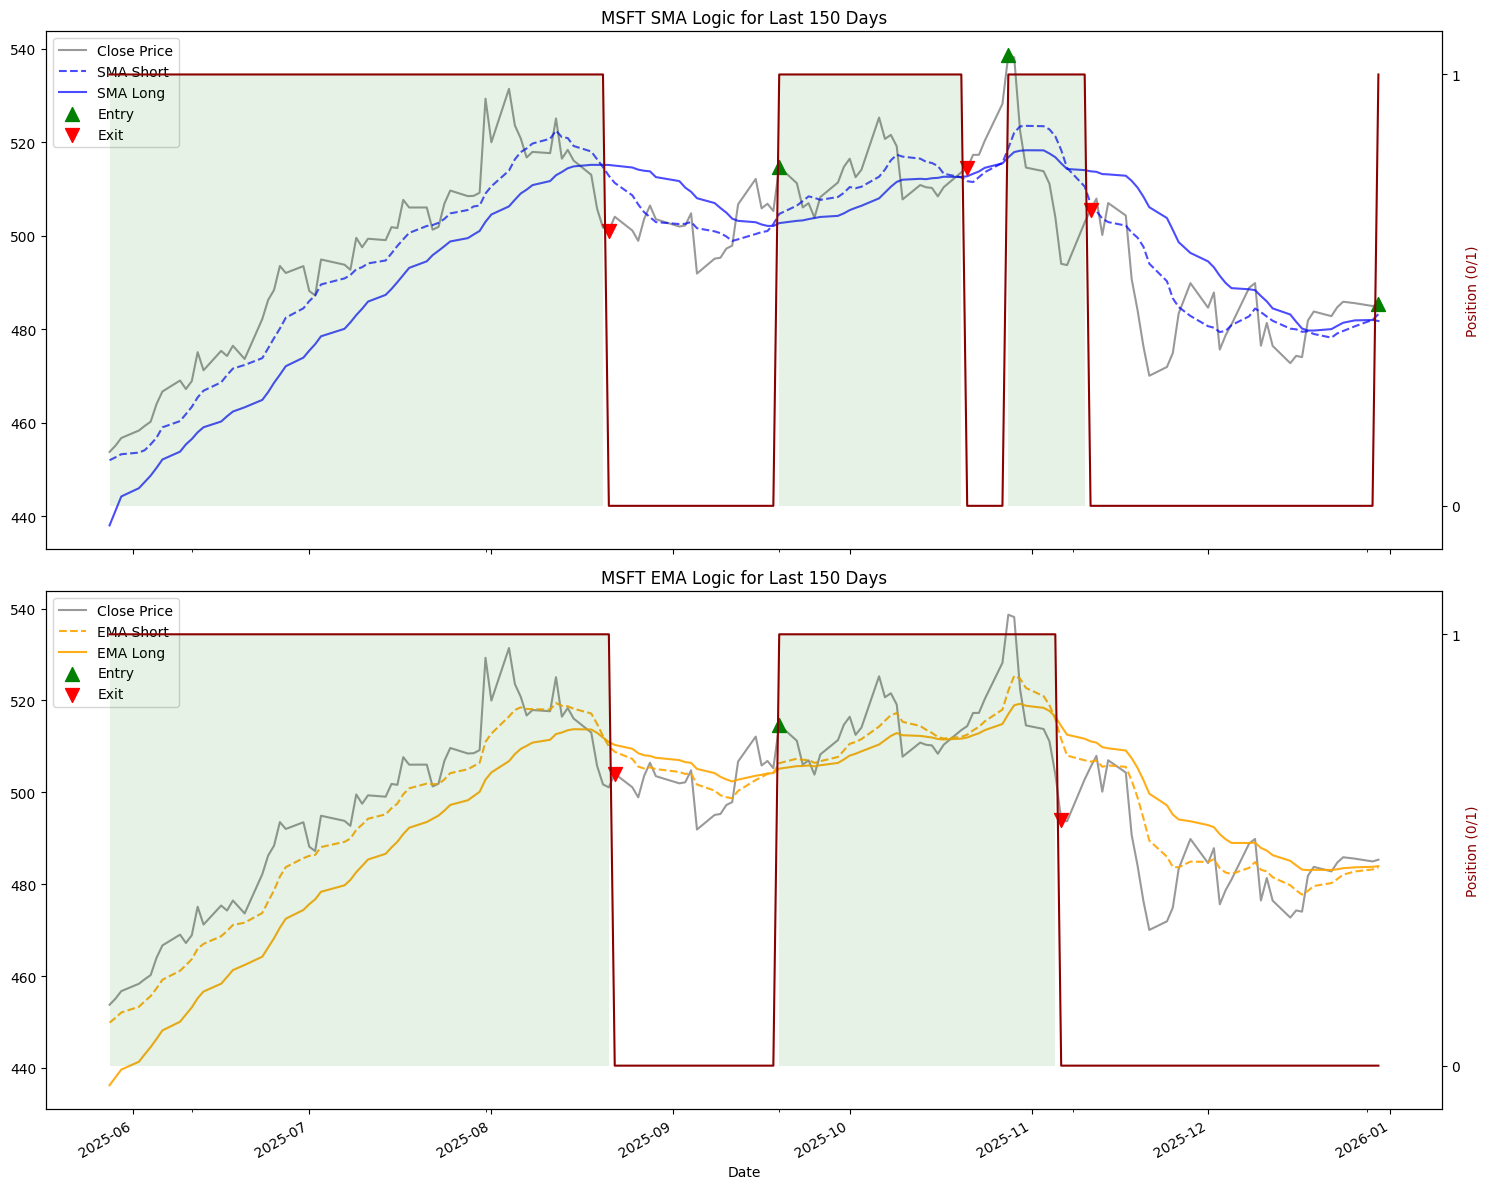

[MSFT] 200 Day Returns:
SMA Strategy: 15.33%
EMA Strategy: 18.64%


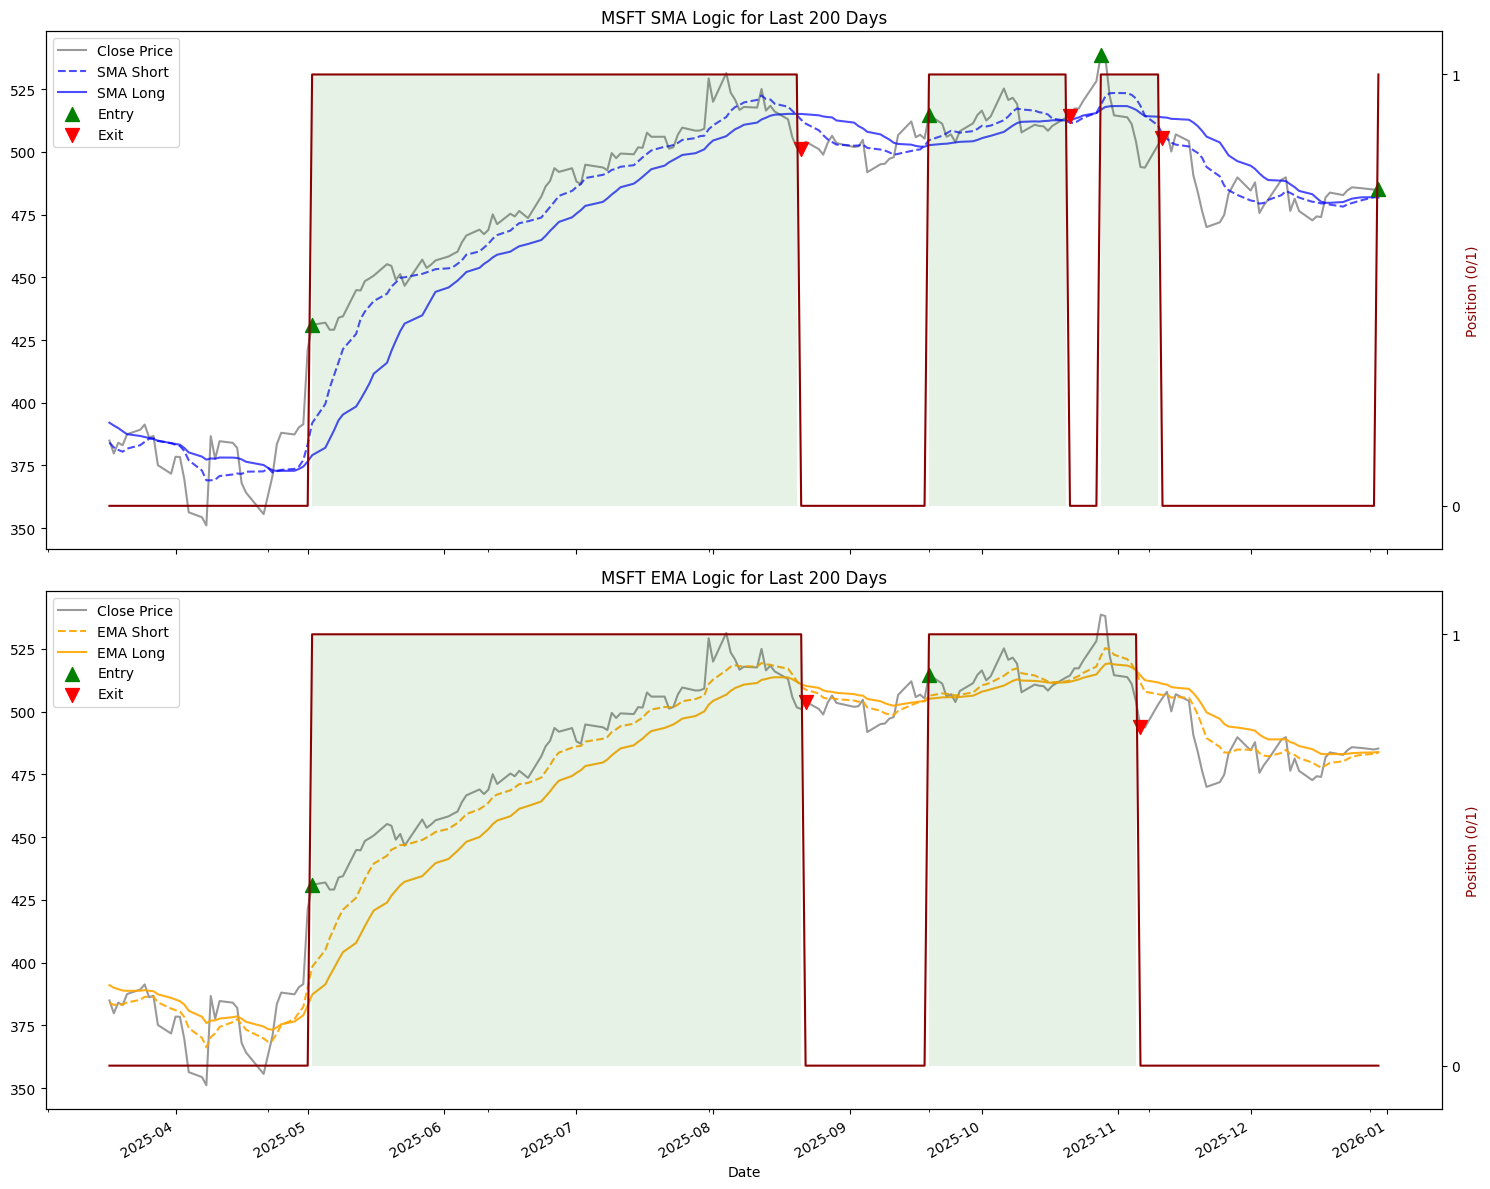

[TSLA] 50 Day Returns:
SMA Strategy: -14.19%
EMA Strategy: -6.92%


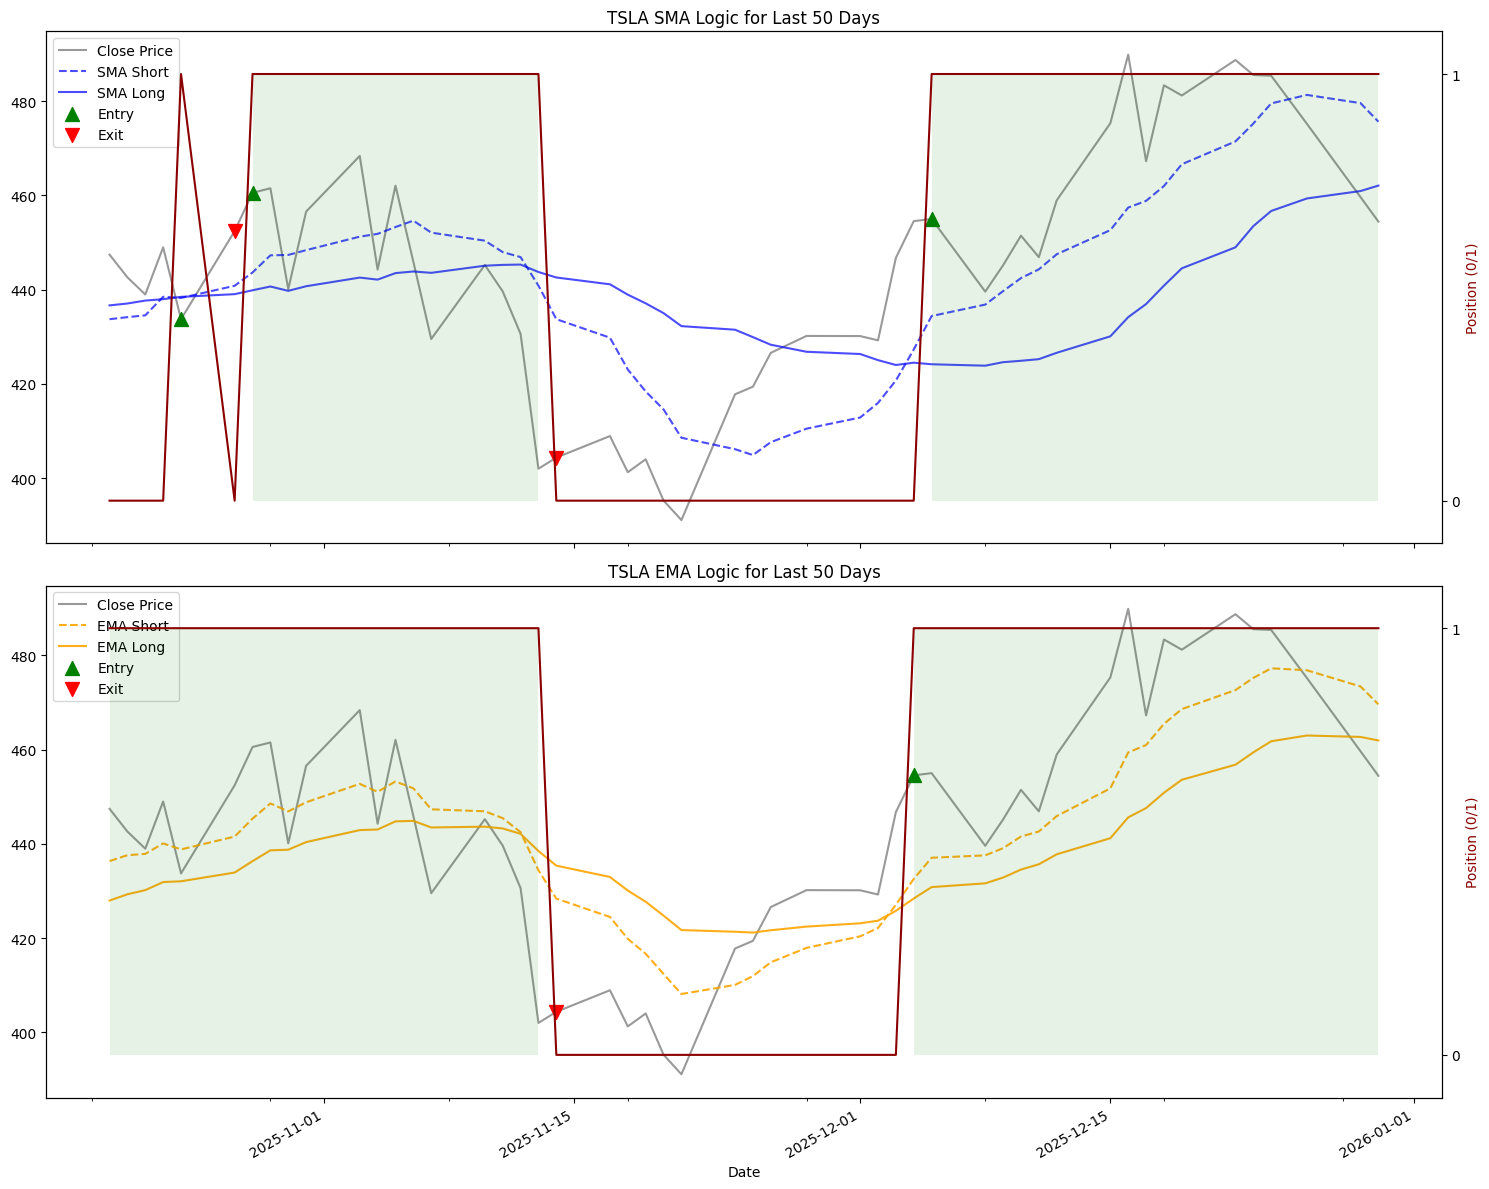

[TSLA] 100 Day Returns:
SMA Strategy: 3.33%
EMA Strategy: 24.04%


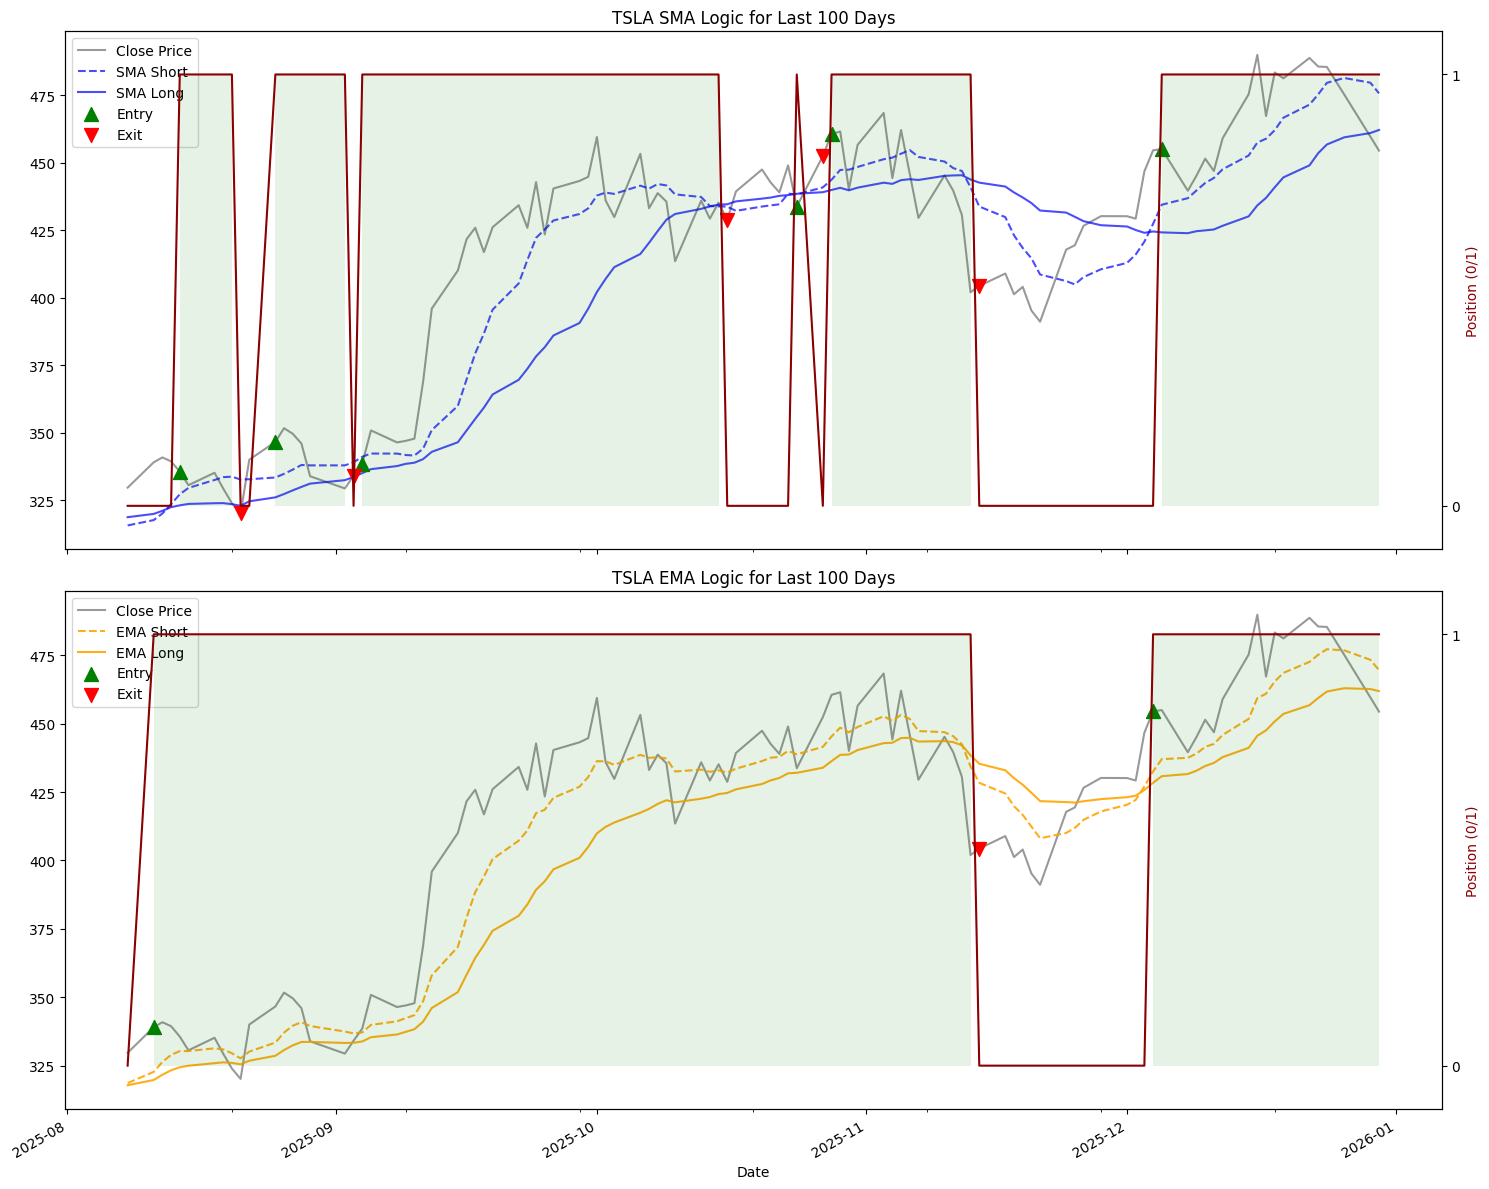

[TSLA] 150 Day Returns:
SMA Strategy: -37.23%
EMA Strategy: -25.39%


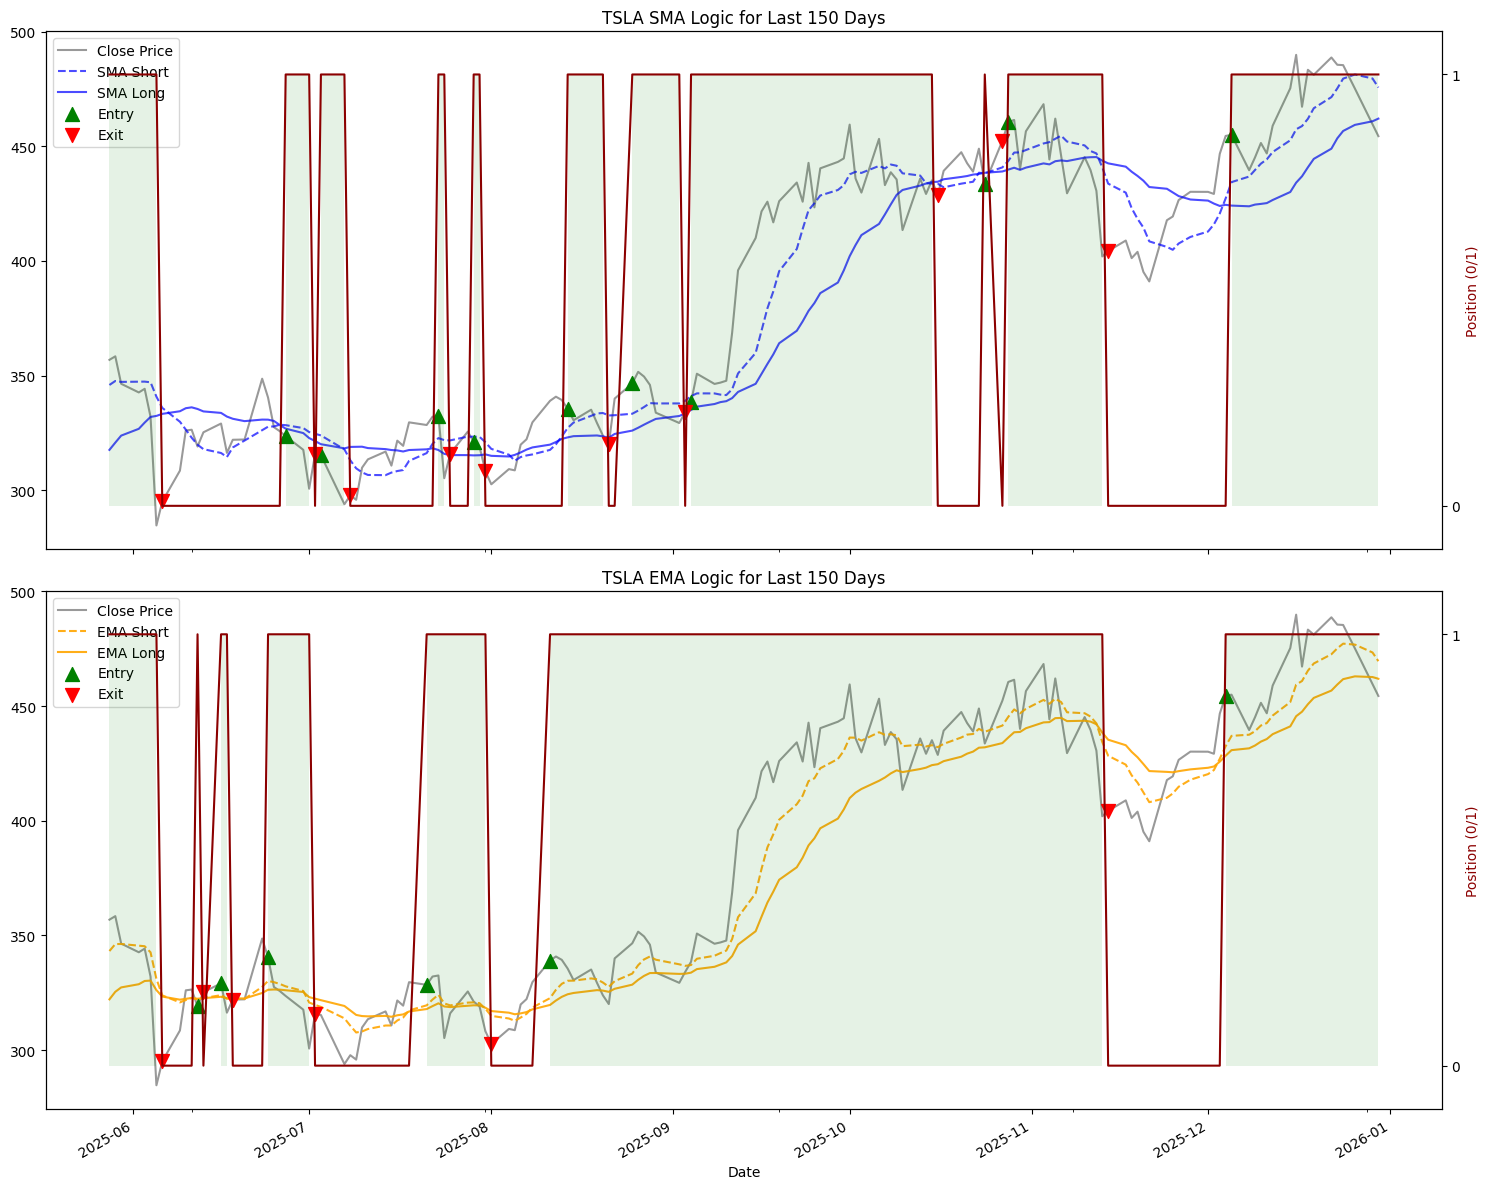

[TSLA] 200 Day Returns:
SMA Strategy: -26.21%
EMA Strategy: -14.41%


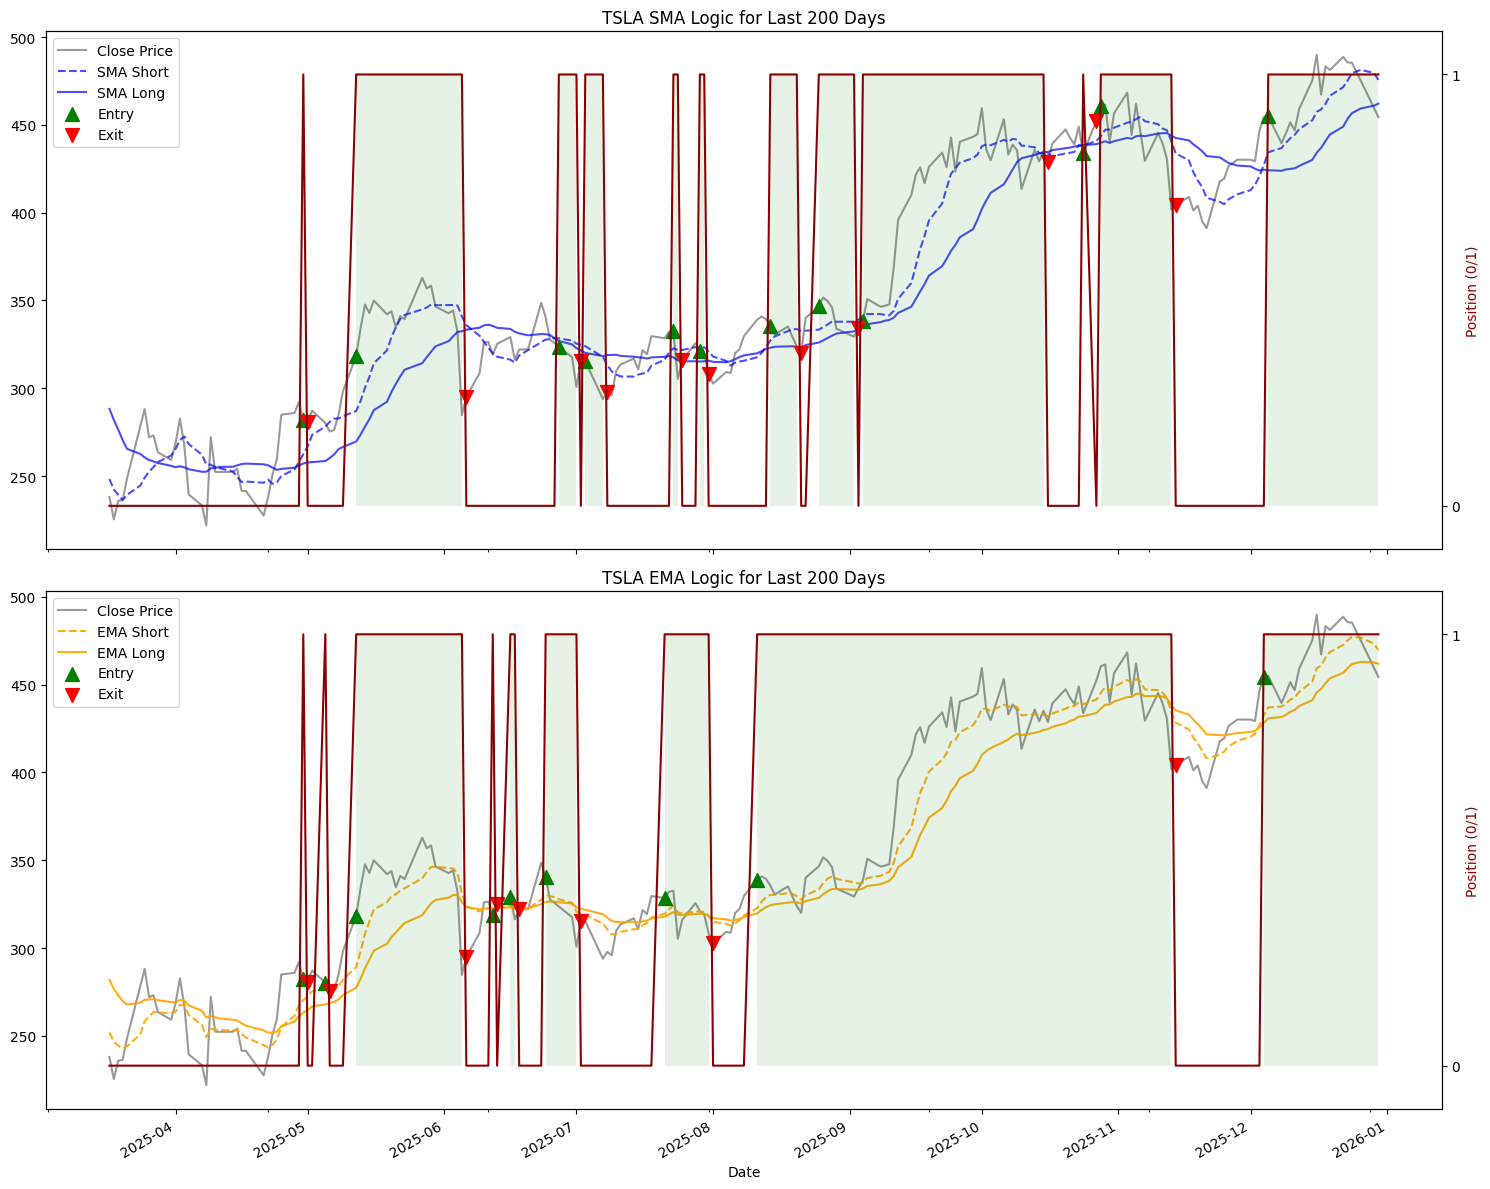

In [64]:
day_windows = [50, 100, 150, 200]

for ticker in CONFIG["tickers"]:
    data = pd.read_parquet(output_dir / f"signals_{ticker}.parquet")
    
    for days in day_windows:
        # Calculate returns for both strategies over this specific window
        ret_sma = (data['returns_SMA'][-days:] + 1).prod() - 1
        ret_ema = (data['returns_EMA'][-days:] + 1).prod() - 1
        
        print(f"[{ticker}] {days} Day Returns:")
        print(f"SMA Strategy: {ret_sma:.2%}")
        print(f"EMA Strategy: {ret_ema:.2%}")
        
        # 1. Prepare subset and detect transitions
        subset = data[-days:].copy()
        sma_diff = subset['final_position_SMA'].diff()
        ema_diff = subset['final_position_EMA'].diff()
        
        # 2. Setup Figure
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
        
        # SMA Subplot 
        ax1.plot(subset.index, subset['Close'], color='black', alpha=0.4, label='Close Price')
        ax1.plot(subset.index, subset['SMA_short'], color='blue', linestyle='--', alpha=0.7, label='SMA Short')
        ax1.plot(subset.index, subset['SMA_long'], color='blue', linestyle='-', alpha=0.7, label='SMA Long')
        
        # Add Entry/Exit Markers
        ax1.scatter(subset[sma_diff == 1].index, subset[sma_diff == 1]['Close'], marker='^', color='green', s=100, label='Entry', zorder=5)
        ax1.scatter(subset[sma_diff == -1].index, subset[sma_diff == -1]['Close'], marker='v', color='red', s=100, label='Exit', zorder=5)
        
        # Secondary axis for position
        sig_plot1 = subset['final_position_SMA'].plot(secondary_y=True, ax=ax1, color='darkred', linewidth=1.5, label='Position')
        sig_plot1.fill_between(subset.index, 0, 1, where=(subset['final_position_SMA'] > 0), color='green', alpha=0.1, lw=0)
        
        ax1.set_title(f'{ticker} SMA Logic for Last {days} Days')
        ax1.legend(loc='upper left')
        sig_plot1.set_ylim(-0.1, 1.1)
        sig_plot1.set_yticks([0, 1])
        sig_plot1.set_ylabel('Position (0/1)', color='darkred')
        
        # EMA Subplot 
        ax2.plot(subset.index, subset['Close'], color='black', alpha=0.4, label='Close Price')
        ax2.plot(subset.index, subset['EMA_short'], color='orange', linestyle='--', alpha=0.9, label='EMA Short')
        ax2.plot(subset.index, subset['EMA_long'], color='orange', linestyle='-', alpha=0.9, label='EMA Long')
        
        # Add Entry/Exit Markers
        ax2.scatter(subset[ema_diff == 1].index, subset[ema_diff == 1]['Close'], marker='^', color='green', s=100, label='Entry', zorder=5)
        ax2.scatter(subset[ema_diff == -1].index, subset[ema_diff == -1]['Close'], marker='v', color='red', s=100, label='Exit', zorder=5)
        
        # Secondary axis for position
        sig_plot2 = subset['final_position_EMA'].plot(secondary_y=True, ax=ax2, color='darkred', linewidth=1.5, label='Position')
        sig_plot2.fill_between(subset.index, 0, 1, where=(subset['final_position_EMA'] > 0), color='green', alpha=0.1, lw=0)
        
        ax2.set_title(f'{ticker} EMA Logic for Last {days} Days')
        ax2.legend(loc='upper left')
        sig_plot2.set_ylim(-0.1, 1.1)
        sig_plot2.set_yticks([0, 1])
        sig_plot2.set_ylabel('Position (0/1)', color='darkred')
        
        plt.tight_layout()
        plt.show()